# A03 — Sparse Routing Design, Objective Variants & Diagnostics
Covers Appendix E – H:
- Table E1: Sparse routing variant comparison
- Figure E1: Route entropy + effective expert count across sparse variants
- Table F1: Objective / regularization variant comparison
- Figure H1: Stage-wise routing diagnostics for behavioral groups


In [ ]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import appendix_viz_helpers as viz
importlib.reload(viz)

apply_style    = viz.apply_style
load_csv       = viz.load_csv
annotate_demo  = viz.annotate_demo
clean_axes     = viz.clean_axes
dataset_label  = viz.dataset_label
metric_limits  = viz.metric_limits
palette_for    = viz.palette_for
bar_line_panel = viz.bar_line_panel
panel_label    = viz.panel_label
PALETTE        = viz.PALETTE
DATASET_LABELS = viz.DATASET_LABELS
apply_style()


In [2]:
sparse  = load_csv('appendix_sparse_tradeoff.csv')        # E: sparse routing variants
obj_df  = load_csv('appendix_objective_variants.csv')     # F: objective / regularization variants
diag_df = load_csv('appendix_sparse_diagnostics.csv')     # H: route entropy / n_eff diagnostics
for df in (sparse, obj_df, diag_df):
    df['dataset_label'] = df['dataset'].map(dataset_label)
print("sparse: ", sparse.shape,  list(sparse.columns))
print("obj_df: ", obj_df.shape,  list(obj_df.columns))
print("diag_df:", diag_df.shape, list(diag_df.columns))


sparse:  (28, 12) ['dataset', 'setting_key', 'setting_label', 'variant_label', 'test_seen_mrr20', 'test_ndcg20', 'active_experts', 'base_rank', 'seed_id', 'data_status', 'data_note', 'dataset_label']
obj_df:  (24, 11) ['dataset', 'setting_key', 'setting_label', 'variant_label', 'test_seen_mrr20', 'test_ndcg20', 'base_rank', 'seed_id', 'data_status', 'data_note', 'dataset_label']
diag_df: (84, 12) ['dataset', 'question', 'setting_key', 'setting_label', 'variant_label', 'stage_key', 'group_entropy_mean', 'group_n_eff', 'group_top1_max_frac', 'data_status', 'data_note', 'dataset_label']


In [ ]:
# ── Figure E1 (chart) — Sparse variant quality: MRR@20 bars + NDCG@20 line per dataset ──
# Each dataset gets its own subplot; variants on x-axis; left y = MRR@20 (seen), right y = NDCG@20.
VARIANT_ORDER = [
    'Dense full mixture', 'Flat sparse top-6',
    'Top-4gr Top-2ex (8 act.)', 'Top-2gr Top-4ex (8 act.)',
    'Top-3gr Top-2ex — main',   'Top-2gr Top-1ex (2 act.)',
    'Top-3gr Top-3ex (9 act.)',
]
VARIANT_SHORT = {
    'Dense full mixture':       'Dense\nfull',
    'Flat sparse top-6':        'Flat\ntop-6',
    'Top-4gr Top-2ex (8 act.)': '4gr\n2ex',
    'Top-2gr Top-4ex (8 act.)': '2gr\n4ex',
    'Top-3gr Top-2ex — main':   '3gr2ex\n(main)',
    'Top-2gr Top-1ex (2 act.)': '2gr\n1ex',
    'Top-3gr Top-3ex (9 act.)': '3gr\n3ex',
}
sparse['variant_short'] = sparse['variant_label'].map(VARIANT_SHORT).fillna(sparse['variant_label'])
short_order = [VARIANT_SHORT.get(v, v) for v in VARIANT_ORDER if VARIANT_SHORT.get(v, v) in sparse['variant_short'].values]

datasets_e = [d for d in ['beauty', 'foursquare', 'KuaiRecLargeStrictPosV2_0.2', 'movielens1m']
              if d in sparse['dataset'].unique()]
fig, axes = plt.subplots(1, len(datasets_e), figsize=(4.0 * len(datasets_e), 3.8),
                          constrained_layout=True)
axes = [axes] if len(datasets_e) == 1 else list(axes)

for ax, ds in zip(axes, datasets_e):
    sub = sparse[sparse['dataset'] == ds].copy()
    bar_line_panel(sub, category_col='variant_short',
                   bar_col='test_seen_mrr20', line_col='test_ndcg20',
                   ax=ax, order=short_order,
                   bar_label='MRR@20 (seen)', line_label='NDCG@20',
                   xrotation=0)
    ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11)

annotate_demo(fig, sparse)
plt.show()


Variant,Active experts,MRR@20 (avg),NDCG@20 (avg)
Dense full mixture,12,0.1496,0.1796
Flat sparse top-6,6,0.1494,0.1792
Top-4gr Top-2ex (8 act.),8,0.1490,0.1788
Top-2gr Top-4ex (8 act.),8,0.1459,0.1751
Top-3gr Top-2ex — main,6,0.1518,0.1821
Top-2gr Top-1ex (2 act.),2,0.1434,0.1721
Top-3gr Top-3ex (9 act.),9,0.1515,0.1818


<Figure size 832x624 with 0 Axes>

In [ ]:
# ── Figure F1 — Objective variant quality: MRR@20 bars + NDCG@20 line per dataset ──────
OBJ_ORDER = [
    'Full objective', 'No auxiliary loss',
    'KNN consistency only', 'Z-loss only',
    'Balance loss only', 'Consistency + Z-loss',
]
OBJ_SHORT = {
    'Full objective':          'Full\nobjective',
    'No auxiliary loss':       'No aux\nloss',
    'KNN consistency only':    'KNN\nconsist.',
    'Z-loss only':             'Z-loss\nonly',
    'Balance loss only':       'Balance\nloss',
    'Consistency + Z-loss':    'Consist.\n+ Z-loss',
}
obj_df['variant_short'] = obj_df['variant_label'].map(OBJ_SHORT).fillna(obj_df['variant_label'])
short_obj_order = [OBJ_SHORT.get(v, v) for v in OBJ_ORDER if OBJ_SHORT.get(v, v) in obj_df['variant_short'].values]

datasets_f = [d for d in ['beauty', 'foursquare', 'KuaiRecLargeStrictPosV2_0.2', 'movielens1m']
              if d in obj_df['dataset'].unique()]
fig, axes = plt.subplots(1, len(datasets_f), figsize=(4.0 * len(datasets_f), 3.8),
                          constrained_layout=True)
axes = [axes] if len(datasets_f) == 1 else list(axes)

for ax, ds in zip(axes, datasets_f):
    sub = obj_df[obj_df['dataset'] == ds].copy()
    bar_line_panel(sub, category_col='variant_short',
                   bar_col='test_seen_mrr20', line_col='test_ndcg20',
                   ax=ax, order=short_obj_order,
                   bar_label='MRR@20 (seen)', line_label='NDCG@20',
                   xrotation=0)
    ax.set_title(DATASET_LABELS.get(ds, ds), fontsize=11)

annotate_demo(fig, obj_df)
plt.show()


ValueError: Unknown format code 'f' for object of type 'str'

<Figure size 832x624 with 0 Axes>

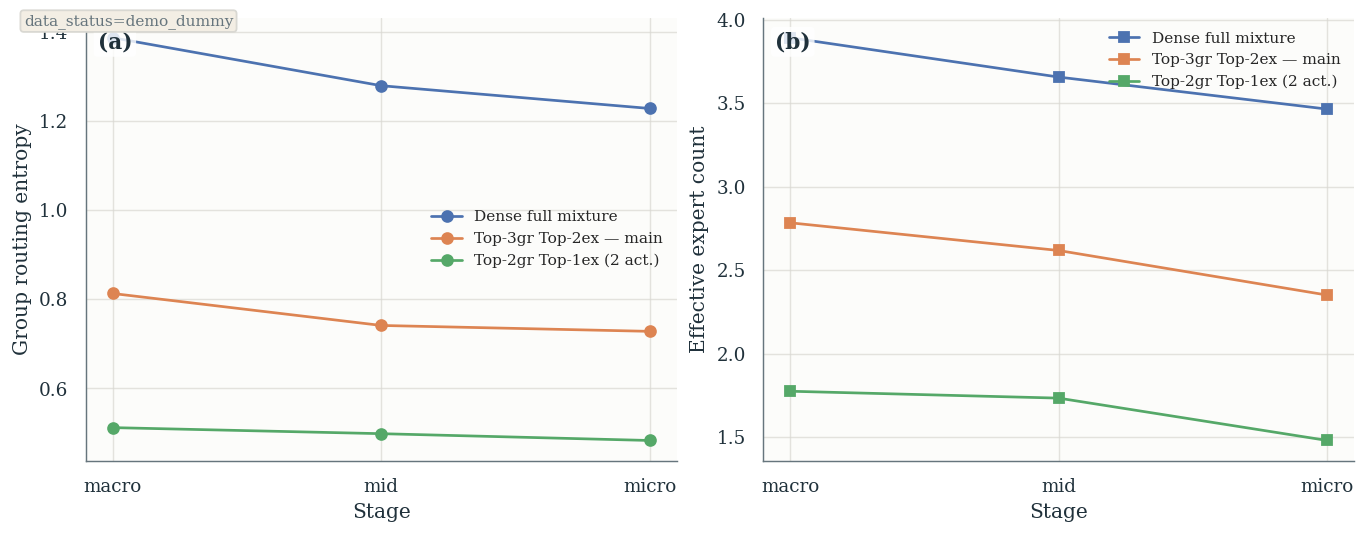

In [ ]:
# ── Figure E2(a) — Route entropy by stage across sparse variants ────────────────
STAGE_ORDER   = ['macro', 'mid', 'micro']
SPARSE_SUBSET = ['Dense full mixture', 'Top-3gr Top-2ex — main', 'Top-2gr Top-1ex (2 act.)']
SUBSET_PAL    = [PALETTE['blue'], PALETTE['route'], PALETTE['rose']]

fig, ax = plt.subplots(figsize=(6.4, 3.8), constrained_layout=True)
for vlabel, col in zip(SPARSE_SUBSET, SUBSET_PAL):
    sub = (
        diag_df[diag_df['variant_label'] == vlabel]
        .groupby('stage_key', as_index=False)['group_entropy_mean'].mean()
    )
    sub['stage_key'] = pd.Categorical(sub['stage_key'], categories=STAGE_ORDER, ordered=True)
    sub = sub.sort_values('stage_key')
    ax.plot(sub['stage_key'], sub['group_entropy_mean'], marker='o', label=vlabel, color=col,
            linewidth=2.1, markersize=5.4)
ax.set_xlabel('Stage')
ax.set_ylabel('Group routing entropy')
ax.legend(fontsize=8.5)
clean_axes(ax)
annotate_demo(fig, diag_df)
plt.show()


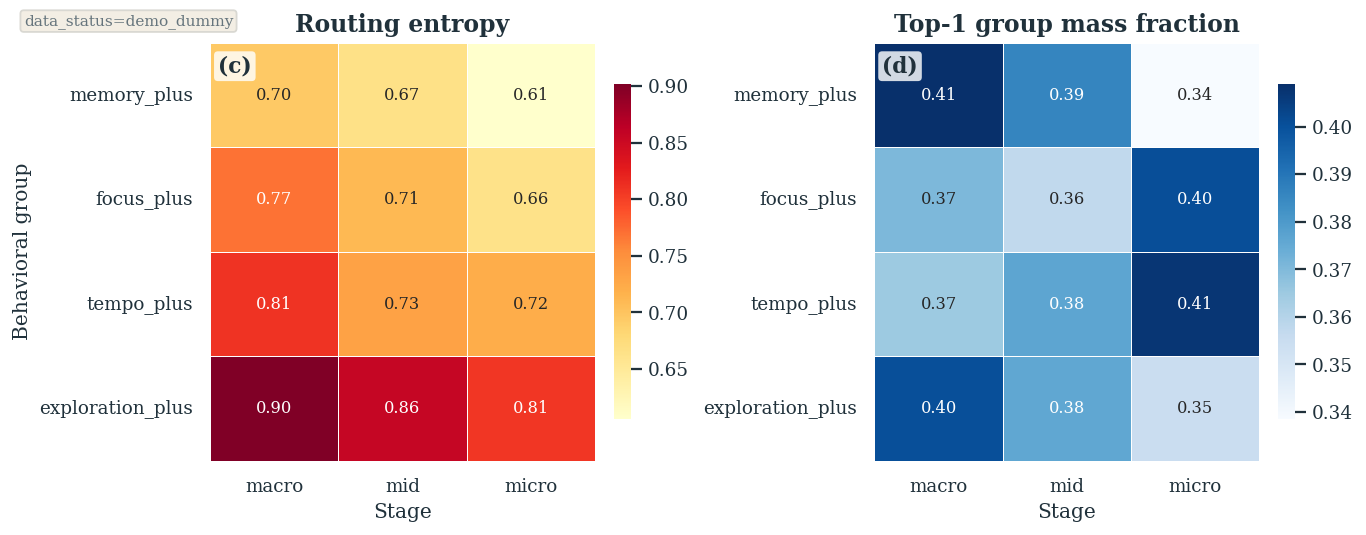

In [ ]:
# ── Figure E2(b) — Effective expert count by stage ───────────────────────────────
fig, ax = plt.subplots(figsize=(6.4, 3.8), constrained_layout=True)
for vlabel, col in zip(SPARSE_SUBSET, SUBSET_PAL):
    sub = (
        diag_df[diag_df['variant_label'] == vlabel]
        .groupby('stage_key', as_index=False)['group_n_eff'].mean()
    )
    sub['stage_key'] = pd.Categorical(sub['stage_key'], categories=STAGE_ORDER, ordered=True)
    sub = sub.sort_values('stage_key')
    ax.plot(sub['stage_key'], sub['group_n_eff'], marker='s', label=vlabel, color=col,
            linewidth=2.1, markersize=5.4)
ax.set_xlabel('Stage')
ax.set_ylabel('Effective expert count')
ax.legend(fontsize=8.5)
clean_axes(ax)
annotate_demo(fig, diag_df)
plt.show()

# ── Figure H1(c) — Routing entropy heatmap (behavioral group × stage) ───────────
route_diag = load_csv('appendix_routing_diagnostics.csv')
route_diag['dataset_label'] = route_diag['dataset'].map(dataset_label)
GROUPS = ['memory_plus', 'focus_plus', 'tempo_plus', 'exploration_plus']

fig, ax = plt.subplots(figsize=(5.8, 3.8), constrained_layout=True)
heat_ent = (
    route_diag
    .groupby(['variant_label', 'stage_key'])['group_entropy_mean']
    .mean()
    .unstack('stage_key')
    .reindex(index=GROUPS, columns=STAGE_ORDER)
)
sns.heatmap(heat_ent, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Stage')
ax.set_ylabel('Behavioral group')
annotate_demo(fig, route_diag)
plt.show()

# ── Figure H1(d) — Top-1 group mass fraction heatmap ────────────────────────────
fig, ax = plt.subplots(figsize=(5.8, 3.8), constrained_layout=True)
heat_top1 = (
    route_diag
    .groupby(['variant_label', 'stage_key'])['group_top1_max_frac']
    .mean()
    .unstack('stage_key')
    .reindex(index=GROUPS, columns=STAGE_ORDER)
)
sns.heatmap(heat_top1, ax=ax, cmap='Blues', annot=True, fmt='.2f',
            annot_kws={'size': 9}, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Stage')
ax.set_ylabel('Behavioral group')
annotate_demo(fig, route_diag)
plt.show()
